# 01 · Análisis exploratorio — Mantenimiento predictivo de motores turbofan

**Objetivo:** estimar la vida útil remanente (RUL, *Remaining Useful Life*) de motores turbofan a partir de sus sensores, como base para un esquema de mantenimiento basado en condición.

**Dataset:** NASA C-MAPSS (*Commercial Modular Aero-Propulsion System Simulation*; Saxena & Goebel, 2008). Simulación de una flota de motores que operan desde un estado sano hasta la falla.

| Subconjunto | Motores train / test | Condiciones de operación | Modos de falla |
|---|---|---|---|
| **FD001** | 100 / 100 | 1 | 1 (HPC) |
| FD002 | 260 / 259 | 6 | 1 (HPC) |
| FD003 | 100 / 100 | 1 | 2 (HPC + fan) |
| FD004 | 248 / 249 | 6 | 2 (HPC + fan) |

El análisis se centra en **FD001**.

**Estructura de los archivos**
- `train_FD001.txt`: series completas, registradas ciclo a ciclo hasta la falla (*run-to-failure*).
- `test_FD001.txt`: series truncadas en un punto previo a la falla.
- `RUL_FD001.txt`: RUL real de cada motor de test en su último ciclo observado (variable a predecir).
- Cada registro contiene `unit`, `cycle`, 3 *settings* operacionales y 21 sensores.

**Contenido:** estructura y calidad de los datos, selección de variables, definición de la variable objetivo y caracterización de las tendencias de degradación.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Permite importar src/ desde notebooks/
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from src.data_processing import (
    load_cmapss, add_train_rul, add_test_rul,
    find_low_variance_columns, get_feature_columns,
    SENSOR_COLS, SETTING_COLS, SENSOR_DESCRIPTIONS, DEFAULT_RUL_CAP,
)

DATA_DIR = ROOT / "data" / "raw"
FIG_DIR = ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
SUBSET = "FD001"

# Estilo de gráficos: una sola paleta para todo el proyecto
BLUE, ORANGE, GRAY = "#2a78d6", "#eb6834", "#b5b3ad"
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.color": "#e6e5e0",
    "grid.linewidth": 0.6,
    "axes.titleweight": "bold",
    "lines.linewidth": 2,
})
pd.set_option("display.max_columns", 30)

## 1. Carga de datos

In [2]:
train, test, rul_test = load_cmapss(DATA_DIR, SUBSET)

print(f"train: {train.shape[0]:,} filas x {train.shape[1]} columnas")
print(f"test : {test.shape[0]:,} filas x {test.shape[1]} columnas")
print(f"RUL  : {rul_test.shape[0]} motores")
train.head()

train: 20,631 filas x 26 columnas
test : 13,096 filas x 26 columnas
RUL  : 100 motores


,unit,cycle,setting_1,setting_2,setting_3,s_1,s_2,s_3,s_4,s_5,s_6,s_7,s_8,s_9,s_10,s_11,s_12,s_13,s_14,s_15,s_16,s_17,s_18,s_19,s_20,s_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,21.61,554.36,2388.06,9046.19,1.3,47.47,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,21.61,553.75,2388.04,9044.07,1.3,47.49,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,21.61,554.26,2388.08,9052.94,1.3,47.27,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,21.61,554.45,2388.11,9049.48,1.3,47.13,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,21.61,554.00,2388.06,9055.15,1.3,47.28,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


## 2. Estructura del dataset y vida útil

In [3]:
life = train.groupby("unit")["cycle"].max().rename("ciclos_hasta_falla")

print(f"Motores en train: {train['unit'].nunique()}")
print(f"Motores en test : {test['unit'].nunique()}")
life.describe().round(1).to_frame()

Motores en train: 100
Motores en test : 100


,ciclos_hasta_falla
count,100.0
mean,206.3
std,46.3
min,128.0
25%,177.0
50%,199.0
75%,229.2
max,362.0


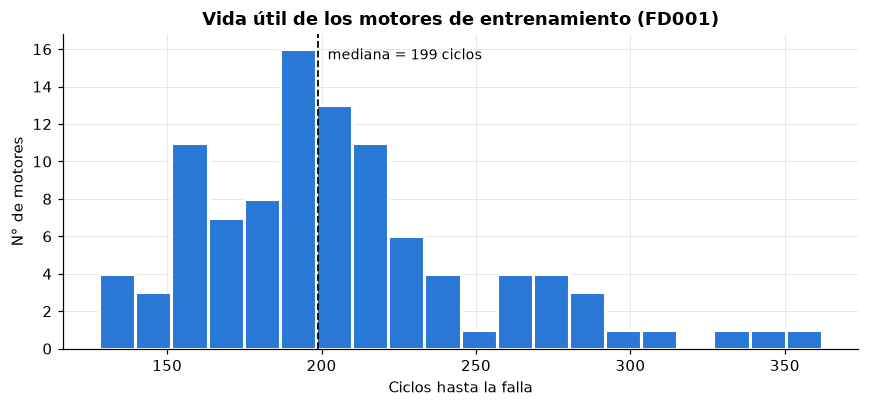

In [4]:
fig, ax = plt.subplots(figsize=(8, 3.8))
ax.hist(life, bins=20, color=BLUE, edgecolor="white", linewidth=2)
ax.axvline(life.median(), color="#0b0b0b", linestyle="--", linewidth=1.2)
ax.annotate(f"mediana = {life.median():.0f} ciclos", xy=(life.median(), ax.get_ylim()[1] * 0.92),
            xytext=(6, 0), textcoords="offset points", fontsize=9)
ax.set_title("Vida útil de los motores de entrenamiento (FD001)")
ax.set_xlabel("Ciclos hasta la falla")
ax.set_ylabel("N° de motores")
plt.tight_layout()
plt.savefig(FIG_DIR / "01_vida_util_motores.png", bbox_inches="tight")
plt.show()

La vida útil en entrenamiento varía entre 128 y 362 ciclos (mediana: 199). La dispersión responde al desgaste inicial y a las variaciones de fabricación de cada motor, no observadas en los datos. En consecuencia, la RUL debe estimarse a partir del estado de cada motor reflejado en sus sensores y no a partir de la vida útil promedio de la flota.

## 3. Calidad de datos

In [5]:
calidad = pd.DataFrame({
    "nulos_train": train.isna().sum(),
    "nulos_test": test.isna().sum(),
})
print(f"Total nulos train: {calidad['nulos_train'].sum()} | test: {calidad['nulos_test'].sum()}")
print(f"Filas duplicadas train: {train.duplicated().sum()} | test: {test.duplicated().sum()}")

# ¿Los ciclos son consecutivos (sin saltos) dentro de cada motor?
saltos = train.groupby("unit")["cycle"].apply(lambda c: (c.diff().dropna() != 1).sum()).sum()
print(f"Saltos en la secuencia de ciclos (train): {saltos}")

Total nulos train: 0 | test: 0
Filas duplicadas train: 0 | test: 0
Saltos en la secuencia de ciclos (train): 0


## 4. Selección de variables

Se descartan las variables con desviación estándar inferior a 0,01, ya que no aportan información sobre la degradación. El criterio se calcula exclusivamente sobre el conjunto de entrenamiento.

In [6]:
var_cols = SETTING_COLS + SENSOR_COLS
resumen = pd.DataFrame({
    "descripcion": [SENSOR_DESCRIPTIONS.get(c, "setting operacional") for c in var_cols],
    "std": train[var_cols].std().values,
    "valores_unicos": train[var_cols].nunique().values,
}, index=var_cols).sort_values("std")
resumen.round(4)

,descripcion,std,valores_unicos
setting_3,setting operacional,0.0000,1
s_1,T2 - Temperatura entrada fan (°R),0.0000,1
s_19,PCNfR_dmd - Velocidad fan corregida demandada ...,0.0000,1
s_18,Nf_dmd - Velocidad fan demandada (rpm),0.0000,1
s_10,epr - Razón de presión del motor,0.0000,1
s_16,farB - Razón combustible/aire del quemador,0.0000,1
s_5,P2 - Presión entrada fan (psia),0.0000,1
setting_2,setting operacional,0.0003,13
s_6,P15 - Presión ducto bypass (psia),0.0014,2
setting_1,setting operacional,0.0022,158


In [7]:
sin_variacion = find_low_variance_columns(train, var_cols)
FEATURES = get_feature_columns(train)

print(f"Columnas descartadas ({len(sin_variacion)}): {sin_variacion}")
print(f"Sensores que se usarán ({len(FEATURES)}): {FEATURES}")

Columnas descartadas (10): ['setting_1', 'setting_2', 'setting_3', 's_1', 's_5', 's_6', 's_10', 's_16', 's_18', 's_19']
Sensores que se usarán (14): ['s_2', 's_3', 's_4', 's_7', 's_8', 's_9', 's_11', 's_12', 's_13', 's_14', 's_15', 's_17', 's_20', 's_21']


Se descartan 10 variables: los tres *settings* operacionales (FD001 opera en una única condición) y los sensores s_1, s_5, s_6, s_10, s_16, s_18 y s_19. El modelado utiliza los 14 sensores restantes.

> En FD002 y FD004, con seis condiciones de operación, los *settings* presentan variación y los sensores deben normalizarse por condición de operación.

## 5. Definición de la variable objetivo

En entrenamiento, cada motor opera hasta la falla, por lo que para cada ciclo:

$$RUL = \text{último ciclo del motor} - \text{ciclo actual}$$

Se adopta una **RUL lineal por tramos con tope de 125 ciclos**, criterio estándar en la literatura de C-MAPSS. Durante la etapa inicial de operación el motor no presenta degradación observable en los sensores, por lo que diferencias de RUL en ese tramo no son aprendibles. El tope representa ese período como un estado sano constante y concentra el aprendizaje en la fase de degradación, que es la relevante para la planificación del mantenimiento.

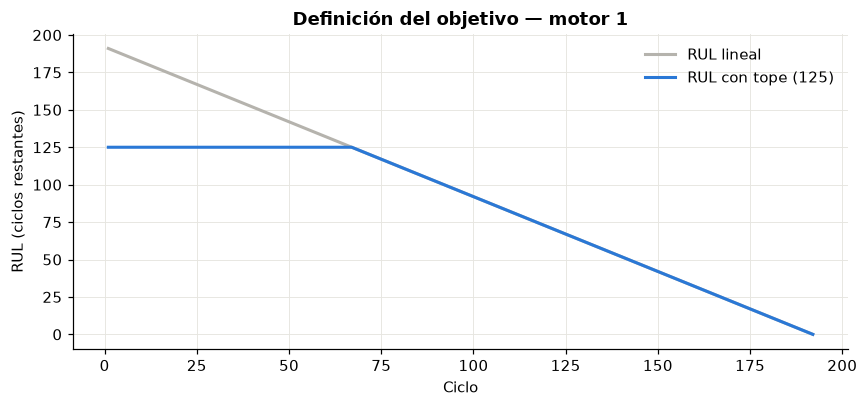

In [8]:
train = add_train_rul(train, cap=DEFAULT_RUL_CAP)

unidad = 1
g = train[train["unit"] == unidad]

fig, ax = plt.subplots(figsize=(8, 3.8))
ax.plot(g["cycle"], g["RUL"], color=GRAY, label="RUL lineal")
ax.plot(g["cycle"], g["RUL_capped"], color=BLUE, label=f"RUL con tope ({DEFAULT_RUL_CAP})")
ax.set_title(f"Definición del objetivo — motor {unidad}")
ax.set_xlabel("Ciclo")
ax.set_ylabel("RUL (ciclos restantes)")
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig(FIG_DIR / "02_rul_con_tope.png", bbox_inches="tight")
plt.show()

## 6. Tendencias de degradación

Las series se alinean por ciclos restantes hasta la falla (eje x = −RUL) para comparar motores de distinta duración. Líneas grises: motores individuales; línea azul: mediana de la flota.

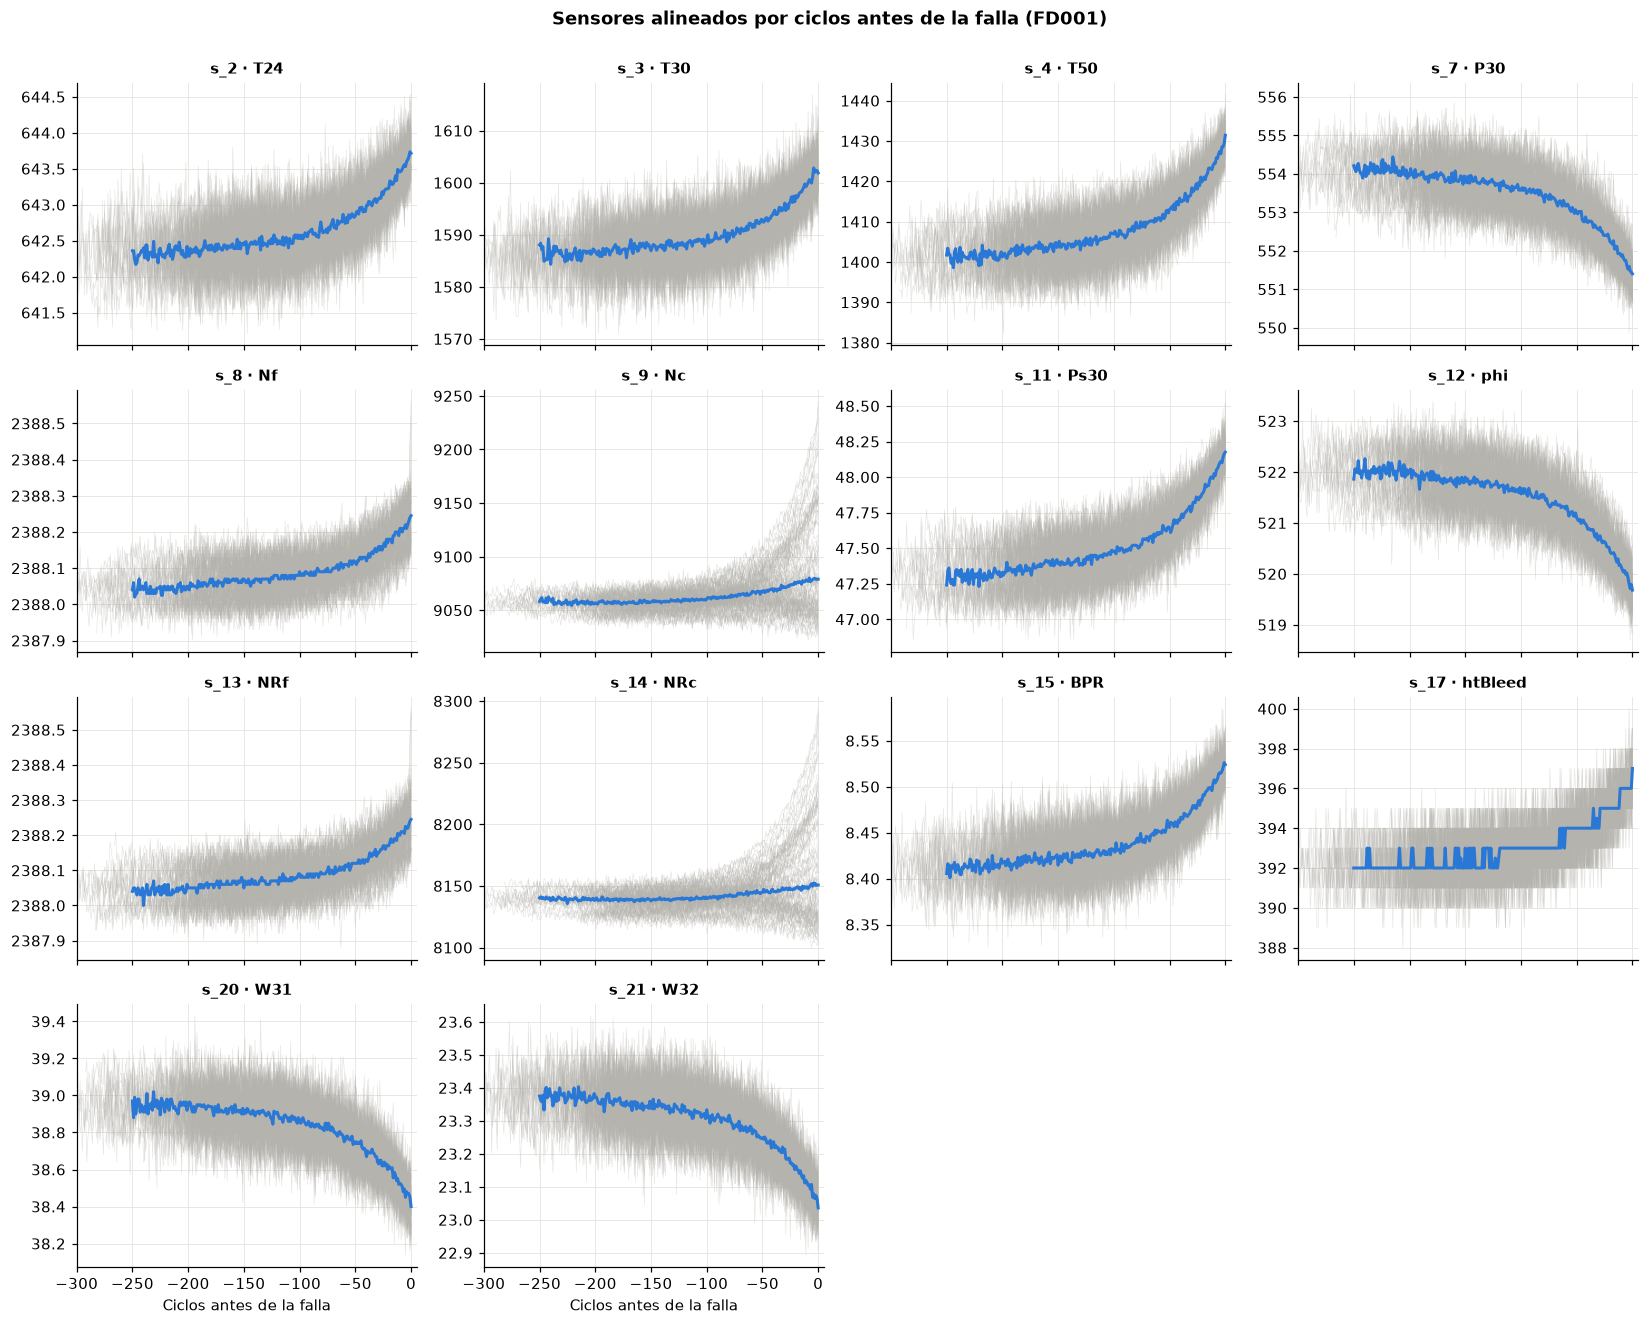

In [9]:
n = len(FEATURES)
ncols = 4
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 3 * nrows), sharex=True)
axes = axes.ravel()

for ax, col in zip(axes, FEATURES):
    for _, g in train.groupby("unit"):
        ax.plot(-g["RUL"], g[col], color=GRAY, linewidth=0.4, alpha=0.35)
    mediana = train.groupby("RUL")[col].median()
    mediana = mediana[mediana.index <= 250]  # poca data más allá: motores muy longevos
    ax.plot(-mediana.index, mediana.values, color=BLUE, linewidth=2)
    ax.set_title(f"{col} · {SENSOR_DESCRIPTIONS[col].split(' - ')[0]}", fontsize=10)
    ax.set_xlim(-300, 5)

for ax in axes[n:]:
    ax.set_visible(False)
for ax in axes[-ncols:]:
    ax.set_xlabel("Ciclos antes de la falla")

fig.suptitle("Sensores alineados por ciclos antes de la falla (FD001)", fontweight="bold", y=1.0)
plt.tight_layout()
plt.savefig(FIG_DIR / "03_tendencias_sensores.png", bbox_inches="tight")
plt.show()

Los sensores permanecen estables durante la mayor parte de la vida útil y presentan una tendencia acelerada en los últimos ~100 ciclos, consistente con la degradación del compresor de alta presión (HPC):

- **Aumentan:** temperaturas (s_2, s_3, s_4), presión estática del HPC (s_11), velocidades del fan (s_8, s_13), razón de bypass (s_15) y entalpía de sangrado (s_17).
- **Disminuyen:** presión de salida del HPC (s_7), razón de flujo de combustible (s_12) y sangrados de refrigerante (s_20, s_21).
- **Heterogéneos:** las velocidades del núcleo (s_9, s_14) siguen trayectorias distintas según el motor.

La forma de las curvas (estable y luego creciente) respalda la RUL con tope definida en la sección anterior. El nivel de ruido ciclo a ciclo indica que el modelado debe basarse en ventanas de varios ciclos y no en observaciones individuales.

## 7. Correlación con la RUL

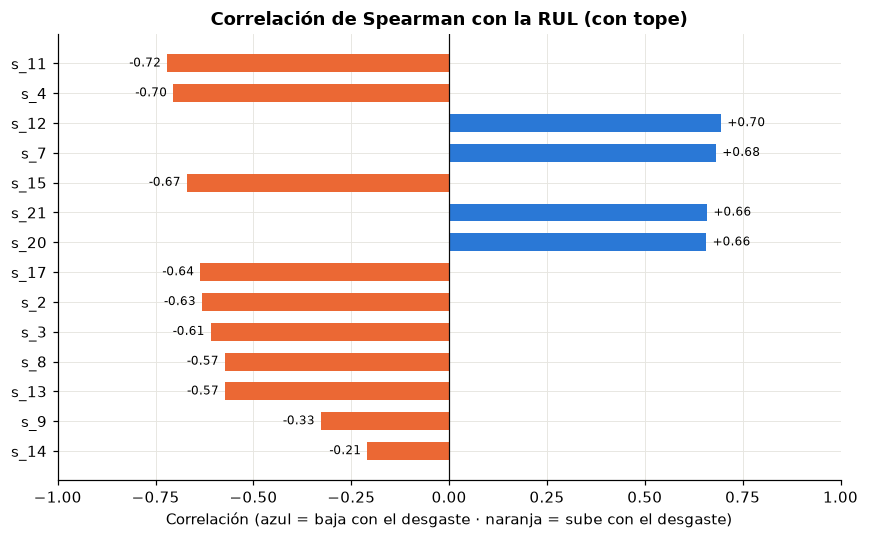

In [10]:
# Spearman: captura relaciones monótonas aunque no sean lineales
corr_rul = (train[FEATURES + ["RUL_capped"]]
            .corr(method="spearman")["RUL_capped"]
            .drop("RUL_capped")
            .sort_values(key=np.abs))

fig, ax = plt.subplots(figsize=(8, 5))
colores = [BLUE if v > 0 else ORANGE for v in corr_rul.values]
ax.barh(corr_rul.index, corr_rul.values, color=colores, height=0.6)
ax.axvline(0, color="#0b0b0b", linewidth=0.8)
for y, v in enumerate(corr_rul.values):
    ax.annotate(f"{v:+.2f}", xy=(v, y), xytext=(4 if v > 0 else -4, 0),
                textcoords="offset points", va="center",
                ha="left" if v > 0 else "right", fontsize=8)
ax.set_title("Correlación de Spearman con la RUL (con tope)")
ax.set_xlabel("Correlación (azul = baja con el desgaste · naranja = sube con el desgaste)")
ax.set_xlim(-1, 1)
plt.tight_layout()
plt.savefig(FIG_DIR / "04_correlacion_rul.png", bbox_inches="tight")
plt.show()

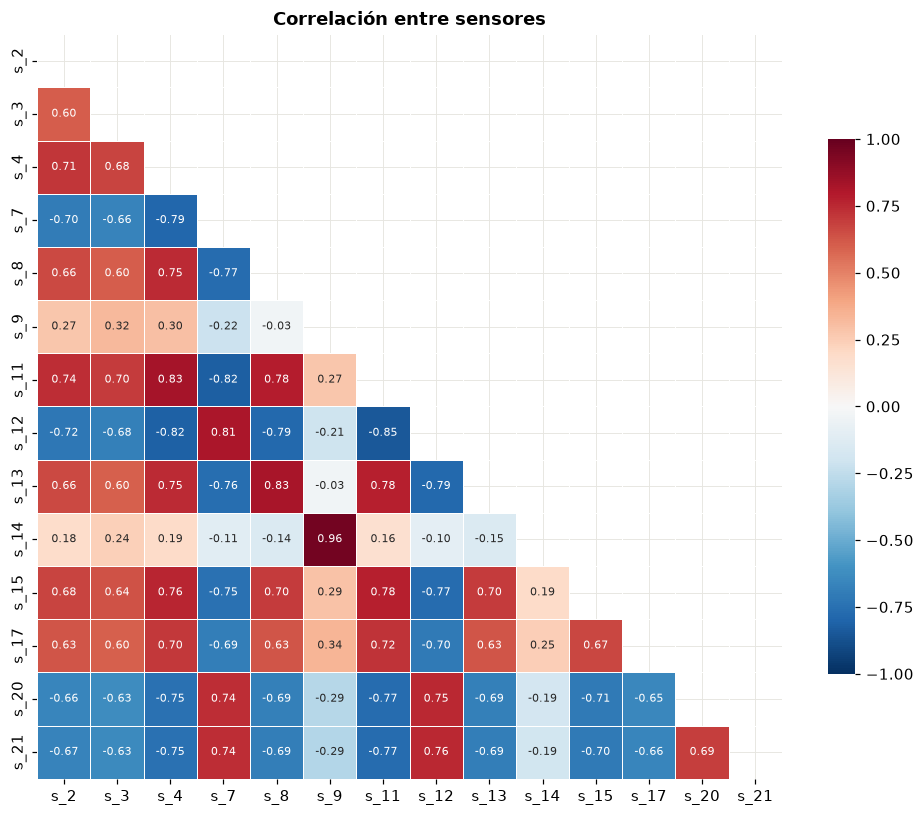

,level_0,level_1,corr
131,s_14,s_9,0.963157


In [11]:
corr = train[FEATURES].corr()

fig, ax = plt.subplots(figsize=(9, 7.5))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            annot=True, fmt=".2f", annot_kws={"size": 7}, square=True,
            linewidths=0.5, cbar_kws={"shrink": 0.7}, ax=ax)
ax.set_title("Correlación entre sensores")
plt.tight_layout()
plt.savefig(FIG_DIR / "05_correlacion_sensores.png", bbox_inches="tight")
plt.show()

# Pares muy redundantes
pares = (corr.where(~mask).stack().rename("corr").reset_index()
         .query("abs(corr) > 0.9").sort_values("corr", key=np.abs, ascending=False))
pares

La única redundancia fuerte corresponde a las velocidades física y corregida del núcleo (s_9 y s_14; r = 0,96), que miden la misma magnitud. Se conservan ambas para los modelos no lineales; en el modelo lineal la redundancia se controla mediante regularización.

## 8. Conjunto de prueba

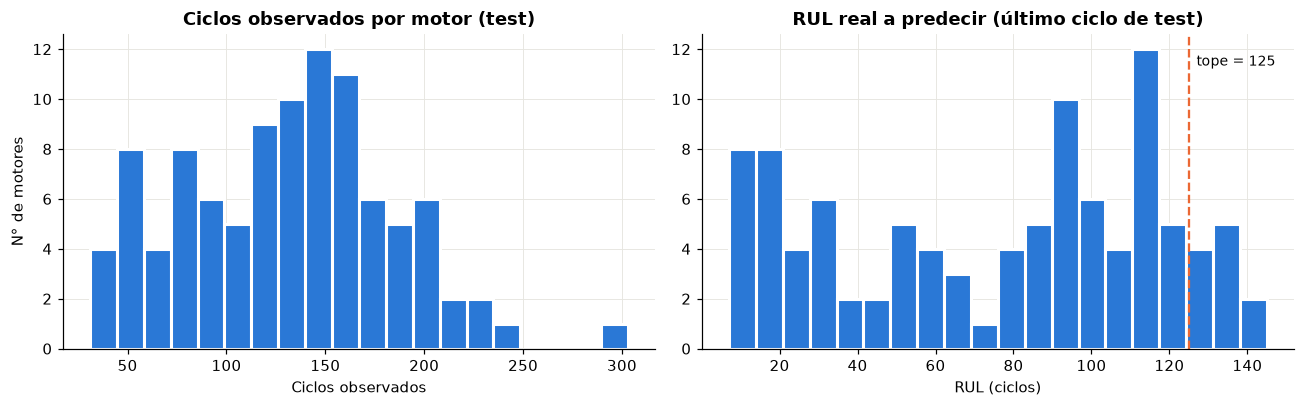

Motor de test más corto: 31 ciclos
RUL real en test: min 7, máx 145, mediana 86
Motores de test con RUL real > tope: 11


In [12]:
test_rul = add_test_rul(test, rul_test, cap=None)
largo_test = test.groupby("unit")["cycle"].max()

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
axes[0].hist(largo_test, bins=20, color=BLUE, edgecolor="white", linewidth=2)
axes[0].set_title("Ciclos observados por motor (test)")
axes[0].set_xlabel("Ciclos observados")
axes[0].set_ylabel("N° de motores")

axes[1].hist(rul_test["RUL_end"], bins=20, color=BLUE, edgecolor="white", linewidth=2)
axes[1].axvline(DEFAULT_RUL_CAP, color=ORANGE, linestyle="--", linewidth=1.5)
axes[1].annotate(f"tope = {DEFAULT_RUL_CAP}", xy=(DEFAULT_RUL_CAP, axes[1].get_ylim()[1] * 0.9),
                 xytext=(5, 0), textcoords="offset points", fontsize=9)
axes[1].set_title("RUL real a predecir (último ciclo de test)")
axes[1].set_xlabel("RUL (ciclos)")
plt.tight_layout()
plt.savefig(FIG_DIR / "06_conjunto_test.png", bbox_inches="tight")
plt.show()

print(f"Motor de test más corto: {largo_test.min()} ciclos")
print(f"RUL real en test: min {rul_test['RUL_end'].min()}, máx {rul_test['RUL_end'].max()}, "
      f"mediana {rul_test['RUL_end'].median():.0f}")
print(f"Motores de test con RUL real > tope: {(rul_test['RUL_end'] > DEFAULT_RUL_CAP).sum()}")

- El motor de test más corto registra 31 ciclos, por lo que una ventana de 30 ciclos cubre todos los motores sin necesidad de relleno.
- La RUL real en test varía entre 7 y 145 ciclos (mediana: 86); 11 motores superan el tope de 125. Para la evaluación, la RUL de test se limita al mismo tope utilizado en entrenamiento, criterio habitual en la literatura de C-MAPSS que permite comparar resultados con otros trabajos.

## 9. Conclusiones

In [13]:
print("RESUMEN FD001")
print(f"- Motores train/test: {train['unit'].nunique()} / {test['unit'].nunique()}")
print(f"- Vida útil en train: {life.min()}–{life.max()} ciclos (mediana {life.median():.0f})")
print(f"- Nulos / duplicados: {int(train.isna().sum().sum())} / {int(train.duplicated().sum())}")
print(f"- Variables descartadas por falta de variación: {len(sin_variacion)}")
print(f"- Sensores para modelar: {len(FEATURES)}")
print(f"- Sensor más asociado a la RUL: {corr_rul.index[-1]} ({corr_rul.iloc[-1]:+.2f})")

RESUMEN FD001
- Motores train/test: 100 / 100
- Vida útil en train: 128–362 ciclos (mediana 199)
- Nulos / duplicados: 0 / 0
- Variables descartadas por falta de variación: 10
- Sensores para modelar: 14
- Sensor más asociado a la RUL: s_11 (-0.72)


**Hallazgos**
1. Datos completos: sin valores nulos, sin duplicados y con ciclos consecutivos.
2. 10 de las 24 variables no presentan variación en FD001; el modelado utiliza 14 sensores.
3. La degradación es no lineal: estable al inicio y acelerada en la fase final. La presión estática del HPC (s_11) es la variable más asociada a la RUL (ρ = −0,72).
4. El ruido ciclo a ciclo requiere modelar ventanas temporales.

**Decisiones de modelado**
- Variable objetivo: RUL lineal por tramos con tope de 125 ciclos.
- Separación entrenamiento/validación por motor, para evitar fuga de información entre conjuntos.
- Escalado Min-Max ajustado solo con datos de entrenamiento.
- Ventanas de 30 ciclos.
- Métricas: RMSE, MAE y NASA score.

**Siguientes etapas:** modelos baseline (`02_baselines.ipynb`) y red LSTM (`03_lstm.ipynb`).